Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 complete. Loss: 0.7219


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Final Results:
Accuracy: 0.50 | F1: 0.00 | Precision: 0.00 | Recall: 0.00


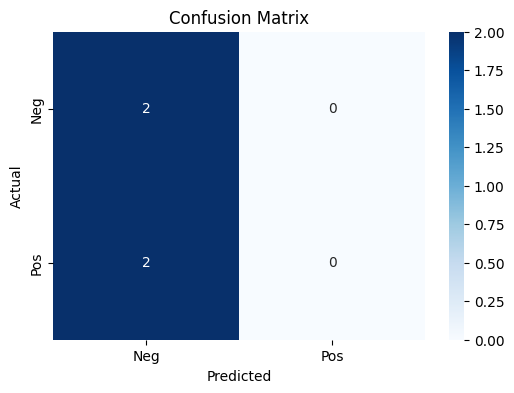

In [4]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Robust Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        # Direct call to tokenizer is more robust than encode_plus
        encoding = self.tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# 3. Model Initialization with Experiment Logic
def initialize_model(experiment_type="fine_tune_last_2"):
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

    if experiment_type == "frozen":
        for param in model.bert.parameters():
            param.requires_grad = False
    elif experiment_type == "fine_tune_last_2":
        for param in model.bert.parameters():
            param.requires_grad = False
        # Unfreeze last 2 encoder layers
        for param in model.bert.encoder.layer[-2:].parameters():
            param.requires_grad = True

    return model.to(device)

# 4. Evaluation Function
def evaluate(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, precision, recall, f1, cm

# --- MAIN EXECUTION ---
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Replace these with your actual Kaggle dataframe columns (e.g., df['text'], df['label'])
sample_texts = ["I loved it!", "Terrible experience.", "Amazing cast.", "Boring plot."]
sample_labels = [1, 0, 1, 0]

dataset = SentimentDataset(sample_texts, sample_labels, tokenizer)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Start Experiment
model = initialize_model("fine_tune_last_2")
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training Loop
model.train()
for epoch in range(1): # Set to 3 for better results
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete. Loss: {loss.item():.4f}")

# Final Evaluation & Visualization
acc, p, r, f1, cm = evaluate(model, loader)
print(f"\nFinal Results:\nAccuracy: {acc:.2f} | F1: {f1:.2f} | Precision: {p:.2f} | Recall: {r:.2f}")

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()